This notebook implements the naive Mono-Forward Algorithm with the gradients

In [8]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


RESULTS_DIR = Path("results")
result_paths = sorted(RESULTS_DIR.glob("*.json"))

result_paths

[WindowsPath('results/mlp_mnist_20260429_111410.json')]

## Training and test losses

In [9]:
def load_experiment_history(path: Path) -> pd.DataFrame:
    raw = pd.read_json(path)
    name_parts = path.stem.split("_")
    model = name_parts[0]
    dataset = name_parts[1]
    run_id = "_".join(name_parts[2:])

    rows = []
    for method in raw.columns:
        for metric, values in raw[method].items():
            for epoch, value in enumerate(values, start=1):
                rows.append(
                    {
                        "file": path.name,
                        "model": model,
                        "dataset": dataset,
                        "run_id": run_id,
                        "method": method,
                        "metric": metric,
                        "epoch": epoch,
                        "value": value,
                    }
                )

    return pd.DataFrame(rows)


history = pd.concat(
    [load_experiment_history(path) for path in result_paths],
    ignore_index=True,
)

losses = (
    history[history["metric"].isin(["train_losses", "test_losses"])]
    .copy()
    .assign(
        split=lambda df: df["metric"].str.replace("_losses", "", regex=False),
        method_label=lambda df: df["method"].map(
            {
                "mono_ff": "MonoFWD FF",
                "mono_bp": "MonoFWD BP",
                "bp": "Backprop",
            }
        ),
    )
)

accuracies = (
    history[history["metric"].isin(["train_accs", "test_accs"])]
    .copy()
    .assign(
        split=lambda df: df["metric"].str.replace("_accs", "", regex=False),
        method_label=lambda df: df["method"].map(
            {
                "mono_ff": "MonoFWD FF",
                "mono_bp": "MonoFWD BP",
                "bp": "Backprop",
            }
        ),
    )
)

display(losses.head())
display(
    losses.groupby(["dataset", "method_label", "split"])["epoch"]
    .max()
    .rename("epochs")
    .to_frame()
)

,file,model,dataset,run_id,method,metric,epoch,value,split,method_label
0,mlp_mnist_20260429_111410.json,mlp,mnist,20260429_111410,mono_ff,train_losses,1,0.637877,train,MonoFWD FF
1,mlp_mnist_20260429_111410.json,mlp,mnist,20260429_111410,mono_ff,train_losses,2,0.289867,train,MonoFWD FF
2,mlp_mnist_20260429_111410.json,mlp,mnist,20260429_111410,mono_ff,train_losses,3,0.204964,train,MonoFWD FF
3,mlp_mnist_20260429_111410.json,mlp,mnist,20260429_111410,mono_ff,train_losses,4,0.150211,train,MonoFWD FF
4,mlp_mnist_20260429_111410.json,mlp,mnist,20260429_111410,mono_ff,train_losses,5,0.124288,train,MonoFWD FF


epochs
dataset method_label split        
mnist   Backprop     test       50
                     train      50
        MonoFWD BP   test       50
                     train      50
        MonoFWD FF   test       50
                     train      50

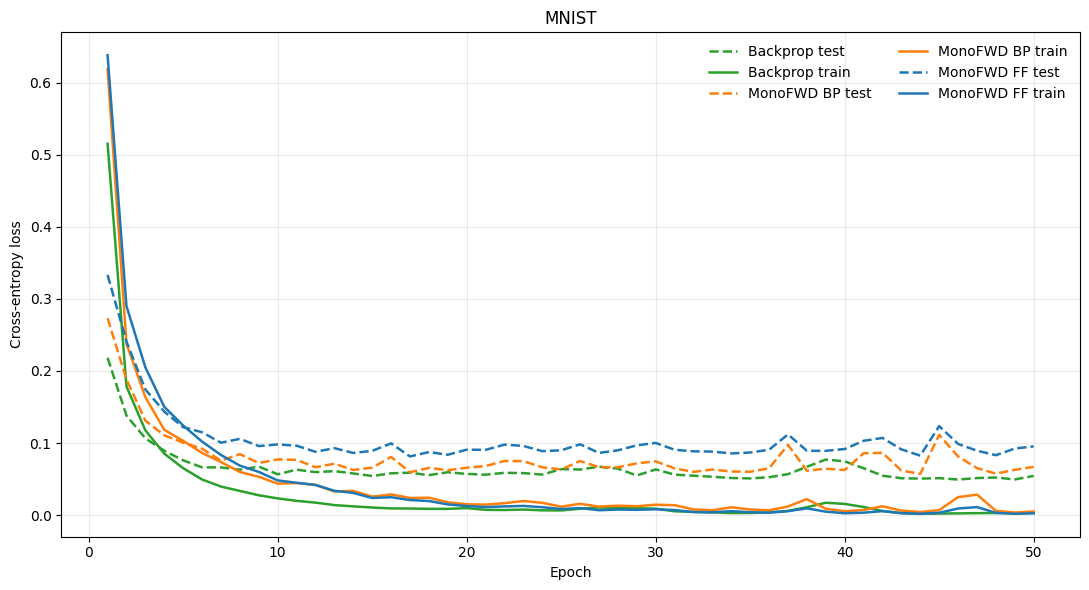

In [10]:
method_colors = {
    "MonoFWD FF": "tab:blue",
    "MonoFWD BP": "tab:orange",
    "Backprop": "tab:green",
}
split_styles = {"train": "-", "test": "--"}

for dataset in sorted(losses["dataset"].unique()):
    fig, ax = plt.subplots(figsize=(11, 6))
    dataset_losses = losses[losses["dataset"] == dataset]

    for (method_label, split), group in dataset_losses.groupby(["method_label", "split"]):
        group = group.sort_values("epoch")
        ax.plot(
            group["epoch"],
            group["value"],
            color=method_colors[method_label],
            linestyle=split_styles[split],
            linewidth=1.8,
            label=f"{method_label} {split}",
        )

    ax.set_title(dataset.upper())
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=2, frameon=False)
    fig.tight_layout()
    plt.show()

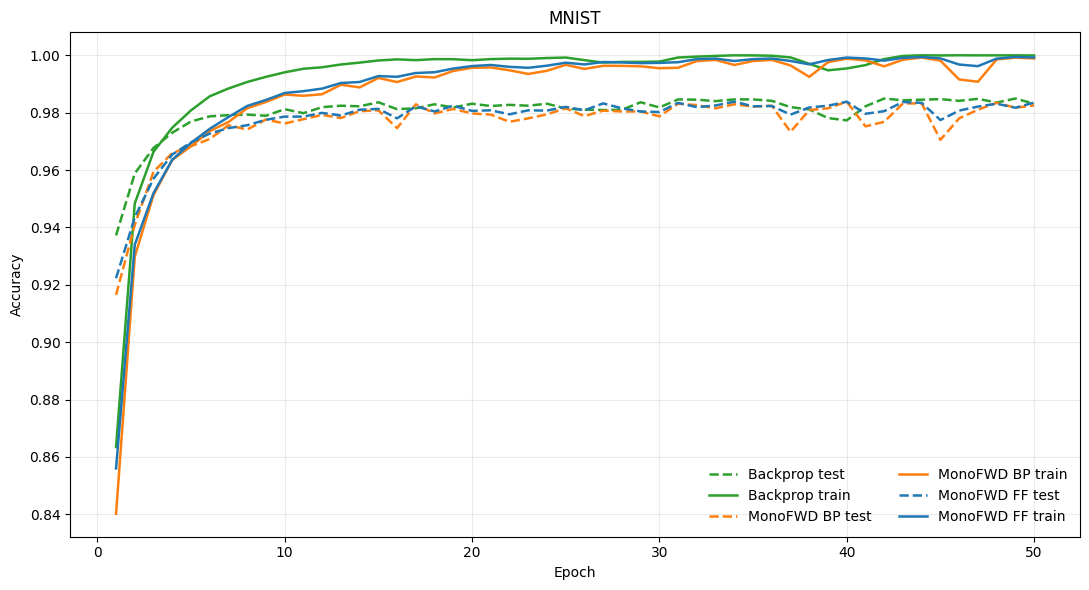

In [11]:
for dataset in sorted(accuracies["dataset"].unique()):
    fig, ax = plt.subplots(figsize=(11, 6))
    dataset_accuracies = accuracies[accuracies["dataset"] == dataset]

    for (method_label, split), group in dataset_accuracies.groupby(["method_label", "split"]):
        group = group.sort_values("epoch")
        ax.plot(
            group["epoch"],
            group["value"],
            color=method_colors[method_label],
            linestyle=split_styles[split],
            linewidth=1.8,
            label=f"{method_label} {split}",
        )

    ax.set_title(dataset.upper())
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=2, frameon=False)
    fig.tight_layout()
    plt.show()